# Title: HDB Resale Housing Affordability in Singapore

## The Question:
## Have HDB resale flats become less affordable for Singaporeans in recent years?

What is done in this project:
1. First looking at price trends
2. Discovering the post-2020 increase
3. Investigating if this is just inflation
4. Comparing with income growth
5. Breaking down by flat types and locations
6. Drawing conclusions and recommendations

Dataset Sources

This project uses three Singapore public datasets:

**1. HDB Resale Flat Prices**
- URL: https://data.gov.sg/dataset/resale-flat-prices
- 5 CSV files covering 1990-2023
- Contains: transaction dates, town, flat type, floor area, resale price

**2. Household Median Income**  
- URL: https://data.gov.sg/dataset/average-and-median-monthly-household-income-from-work
- Annual data from 2000-2023
- Contains: median monthly household income

**3. Consumer Price Index (CPI)**
- URL: https://data.gov.sg/dataset/consumer-price-index-cpi
- Monthly data for inflation adjustment
- Contains: CPI values by month

These datasets are inter-related and allow affordability analysis rather than simple price trend analysis.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# PART 1: Loading and Cleaning the Data

In [3]:
# Load resale data
resale1 = pd.read_csv("Resale Flat Prices (Based on Approval Date), 1990 - 1999.csv")
resale2 = pd.read_csv("Resale Flat Prices (Based on Approval Date), 2000 - Feb 2012.csv")
resale3 = pd.read_csv("Resale Flat Prices (Based on Registration Date), From Mar 2012 to Dec 2014.csv")
resale4 = pd.read_csv("Resale Flat Prices (Based on Registration Date), From Jan 2015 to Dec 2016.csv")
resale5 = pd.read_csv("Resale flat prices based on registration date from Jan-2017 onwards.csv")

# Combine into one DataFrame
resale = pd.concat([resale1, resale2, resale3, resale4, resale5], ignore_index=True)

# Load income and CPI data
income = pd.read_csv("AverageandMedianMonthlyHouseholdIncomefromWorkExcludingEmployerCPFContributionsAmongResidentandResidentEmployedHouseholdsHouseholdIncomeFromWorkAnnual20002023.csv")
cpi = pd.read_csv("ConsumerPriceIndexCPI2024AsBaseYearMonthly.csv")

print(f"Total resale data loaded: {resale.shape}")
print(f"Total income data loaded: {income.shape}")
print(f"Total cpi data loaded: {cpi.shape}")

Total resale data loaded: (971330, 11)
Total income data loaded: (24, 5)
Total cpi data loaded: (207, 781)


In [4]:
# Data Cleaning
resale['month'] = pd.to_datetime(resale['month'], errors='coerce')
resale['resale_price'] = pd.to_numeric(resale['resale_price'], errors='coerce')
resale['floor_area_sqm'] = pd.to_numeric(resale['floor_area_sqm'], errors='coerce')

resale = resale.dropna(subset=['month', 'resale_price', 'floor_area_sqm'])

resale['year'] = resale['month'].dt.year

# Quick look at the data using numpy
prices = resale[resale['year'] >= 2000]['resale_price']

print("Quick Statistics by numpy")
print()
print(f"Mean price:      ${np.mean(prices):.0f}")
print(f"Median price:    ${np.median(prices):.0f}")
print(f"Std deviation:   ${np.std(prices):.0f}")
print(f"Price range:     ${np.min(prices):.0f} - ${np.max(prices):.0f}")

Quick Statistics by numpy

Mean price:      $384068
Median price:    $355000
Std deviation:   $182947
Price range:     $28000 - $1658888


# PART 2: The Big Picture - What's Happening to Prices?

In [8]:
# Prepare Data for Analysis
# Calculate yearly median prices
yearly_price = resale.groupby('year')['resale_price'].median().reset_index()
# yearly_price = yearly_price[(yearly_price['year'] >= 2000) & (yearly_price['year'] <= 2023)]

# plt.figure(figsize=(12, 6))
# plt.plot(yearly_price['year'], yearly_price['resale_price'], 
#          marker='o', linewidth=2.5, markersize=8, color='blue')
# plt.title("Median HDB Resale Price (2000-2023)", fontsize=16, fontweight='bold')
# plt.xlabel("Year", fontsize=13)
# plt.ylabel("Median Price ($)", fontsize=13)
# plt.grid(True, alpha=0.3)
# plt.show()
yearly_price

,year,resale_price
0,1990,52500.0
1,1991,57000.0
2,1992,64000.0
3,1993,103000.0
4,1994,152000.0
5,1995,188000.0
6,1996,248000.0
7,1997,290000.0
8,1998,240000.0
9,1999,236000.0


### FIRST DISCOVERY: A Sharp Increase After 2020!

What we see:
- Gradual growth from 2000-2007
- Sharp rise 2007-2013 
- Plateau 2014-2019 (looks flat)
- Huge spike 2020-2023

Key Question This Raises:
What happened after 2020 that caused such a dramatic increase?

In [15]:
# Lets quantify this increase
price_2019 = yearly_price[yearly_price['year'] == 2019]['resale_price'].values[0]
# price_2023 = yearly_price[yearly_price['year'] == 2023]['resale_price'].values[0]
# increase_pct = ((price_2023 - price_2019) / price_2019) * 100

# print("QUANTIFYING THE POST-2020 SURGE")
# print()
# print(f"2019 median price: ${price_2019:.0f}")
# print(f"2023 median price: ${price_2023:.0f}")
# print(f"Increase: ${price_2023 - price_2019:.0f} (+{increase_pct}%)")
# print(f"\nThat's a {increase_pct:.1f}% increase in just 4 years!")
print(price_2019)

400000.0


Why Did This Happen?

Research shows several factors:
1. **COVID-19 Supply Shock (2020-2021)**: BTO construction delayed 6-12 months, reducing supply
2. **Work-From-Home Demand**: Circuit breaker and WFH policies made people want more space
3. **Low Interest Rates**: HDB loan rates at historic lows (2.6%), making borrowing cheaper
4. **Pent-Up Demand**: Buyers who delayed purchases in 2020 rushed in during 2021-2022

But is this just inflation making everything more expensive?

# PART 3: Is It Just Inflation?

In [32]:
# To answer whether the price increase is "real" or just inflation, CPI data is needed.
# Clean CPI data
cpi_all = cpi[cpi['DataSeries'] == "All Items"]
cpi_long = cpi_all.melt(id_vars='DataSeries', var_name='year_month', value_name='cpi')
cpi_long['year'] = cpi_long['year_month'].str[:4].astype(int)
cpi_long['cpi'] = pd.to_numeric(cpi_long['cpi'], errors='coerce')
cpi_long = cpi_long[(cpi_long['year'] >= 2000) & (cpi_long['year'] <= 2023)]

# # Get yearly average
cpi_yearly = cpi_long.groupby('year')['cpi'].mean().reset_index()

# # Merge with price data
merged = yearly_price.merge(cpi_yearly, on='year')
merged

,year,resale_price,cpi
0,2000,239000.0,63.941667
1,2001,225000.0,64.590417
2,2002,215000.0,64.337417
3,2003,217000.0,64.651000
4,2004,223500.0,65.731917
5,2005,225000.0,66.043083
6,2006,228000.0,66.680833
7,2007,250000.0,68.087667
8,2008,305000.0,72.605583
9,2009,330000.0,73.033333


Real Price Formula: Real Price = Nominal Price × (Base Year CPI / Current Year CPI)

In [138]:
# Calculate real price (adjusted for inflation to 2023 dollars)
base_cpi = merged[merged['year'] == 2023]['cpi'].values[0]
merged['real_price'] = merged['resale_price'] * (base_cpi / merged['cpi'])

print(merged)

    year  resale_price        cpi     real_price
0   2000      239000.0  63.941667  365055.757852
1   2001      225000.0  64.590417  340219.879110
2   2002      215000.0  64.337417  326377.412574
3   2003      217000.0  64.651000  327815.693751
4   2004      223500.0  65.731917  332082.878941
5   2005      225000.0  66.043083  332736.490195
6   2006      228000.0  66.680833  333948.181012
7   2007      250000.0  68.087667  358605.388641
8   2008      305000.0  72.605583  410275.019024
9   2009      330000.0  73.033333  441304.210406
10  2010      365944.0  75.099333  475908.874211
11  2011      410000.0  79.042917  506601.129133
12  2012      445000.0  82.663750  525763.172088
13  2013      455000.0  84.618250  525161.174845
14  2014      420000.0  85.492500  479806.942129
15  2015      405000.0  85.046250  465098.681600
16  2016      410000.0  84.595667  473348.487117
17  2017      410000.0  85.083583  470634.043191
18  2018      408000.0  85.456917  466292.250579
19  2019      400000

**What is "Real Price"?**
It adjusts old prices to 2023 dollars, so we can compare apples-to-apples. \
Two conditions: \
If real price stayed flat, the increase would be ONLY inflation. \
If real price also increased, it's a GENUINE price increase.

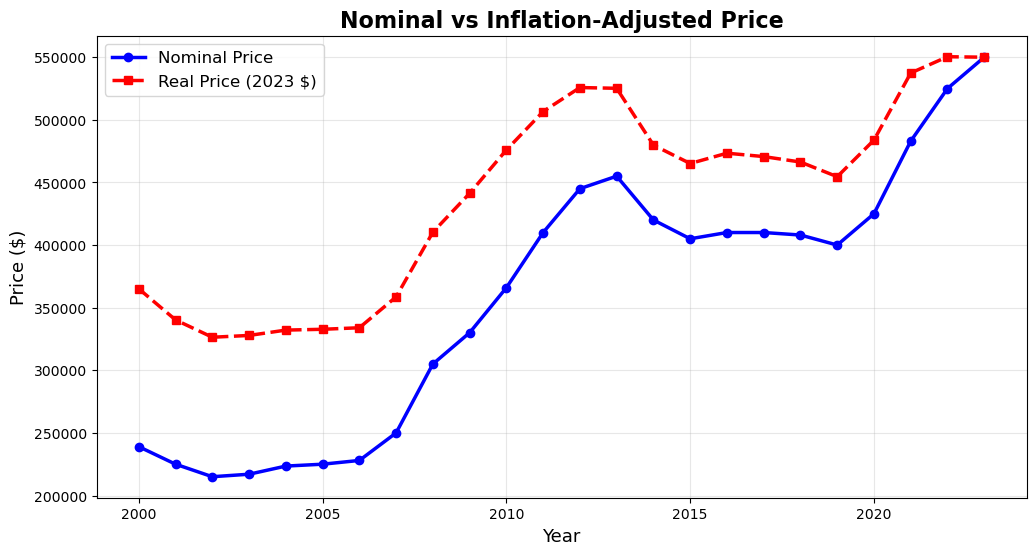

In [101]:
plt.figure(figsize=(12, 6))
plt.plot(merged['year'], merged['resale_price'], 
         marker='o', linewidth=2.5, label="Nominal Price", color='blue')
plt.plot(merged['year'], merged['real_price'], 
         marker='s', linewidth=2.5, label="Real Price (2023 $)", color='red', linestyle='--')
plt.title("Nominal vs Inflation-Adjusted Price", fontsize=16, fontweight='bold')
plt.xlabel("Year", fontsize=13)
plt.ylabel("Price ($)", fontsize=13)
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

In [102]:
# Calculate real price growth
real_2019 = merged[merged['year'] == 2019]['real_price'].values[0]
real_2023 = merged[merged['year'] == 2023]['real_price'].values[0]
real_surge = ((real_2023 - real_2019) / real_2019) * 100

print("ANSWER: Is it just inflation?")
print()
print(f"Real price (inflation-adjusted) 2019: ${real_2019:.0f}")
print(f"Real price (inflation-adjusted) 2023: ${real_2023:.0f}")
print(f"Real increase: +{real_surge:.1f}%")

ANSWER: Is it just inflation?

Real price (inflation-adjusted) 2019: $454568
Real price (inflation-adjusted) 2023: $550000
Real increase: +21.0%


NO! Even after adjusting for inflation\
prices increased by 21%\
This is a GENUINE price increase!

### SECOND DISCOVERY: It's NOT Just Inflation!

The red line (real price) ALSO went up sharply after 2020.\
This confirms that housing genuinely became more expensive, not just money becoming less valuable.

# PART 4: But Can People Afford It?

Prices went up - that's clear. \
But what about household incomes? \
Maybe people are earning more too?

In [34]:
# Clean income data
income = income.rename(columns={
    'Dollar': 'year',
    'ResidentHouseholds_Median1': 'median_income'
})
income_clean = income[['year', 'median_income']]

# Merge with existing data
merged = merged.merge(income_clean, on='year')

print(merged)

    year  resale_price        cpi  median_income
0   2000      239000.0  63.941667           3638
1   2001      225000.0  64.590417           3860
2   2002      215000.0  64.337417           3628
3   2003      217000.0  64.651000           3601
4   2004      223500.0  65.731917           3689
5   2005      225000.0  66.043083           3860
6   2006      228000.0  66.680833           4000
7   2007      250000.0  68.087667           4375
8   2008      305000.0  72.605583           4946
9   2009      330000.0  73.033333           4850
10  2010      365944.0  75.099333           5000
11  2011      410000.0  79.042917           5624
12  2012      445000.0  82.663750           6000
13  2013      455000.0  84.618250           6257
14  2014      420000.0  85.492500           6500
15  2015      405000.0  85.046250           6819
16  2016      410000.0  84.595667           6804
17  2017      410000.0  85.083583           6913
18  2018      408000.0  85.456917           6984
19  2019      400000

Index Formula: Index = (Current Value / Base Value) × 100

In [36]:
# Now with prices AND incomes. Lets compare their growth rates
# Calculate growth indices (both start at 100 in year 2000)
price_index = (merged['resale_price'] / merged['resale_price'].iloc[0]) * 100
income_index = (merged['median_income'] / merged['median_income'].iloc[0]) * 100
print(price_index)
print(income_index)

0     100.000000
1      94.142259
2      89.958159
3      90.794979
4      93.514644
5      94.142259
6      95.397490
7     104.602510
8     127.615063
9     138.075314
10    153.114644
11    171.548117
12    186.192469
13    190.376569
14    175.732218
15    169.456067
16    171.548117
17    171.548117
18    170.711297
19    167.364017
20    177.824268
21    202.092050
22    219.665272
23    230.125523
Name: resale_price, dtype: float64
0     100.000000
1     106.102254
2      99.725124
3      98.982958
4     101.401869
5     106.102254
6     109.950522
7     120.258384
8     135.953821
9     133.315008
10    137.438153
11    154.590434
12    164.925783
13    171.990104
14    178.669599
15    187.438153
16    187.025838
17    190.021990
18    191.973612
19    192.413414
20    187.190764
21    199.587686
22    208.493678
23    225.288620
Name: median_income, dtype: float64


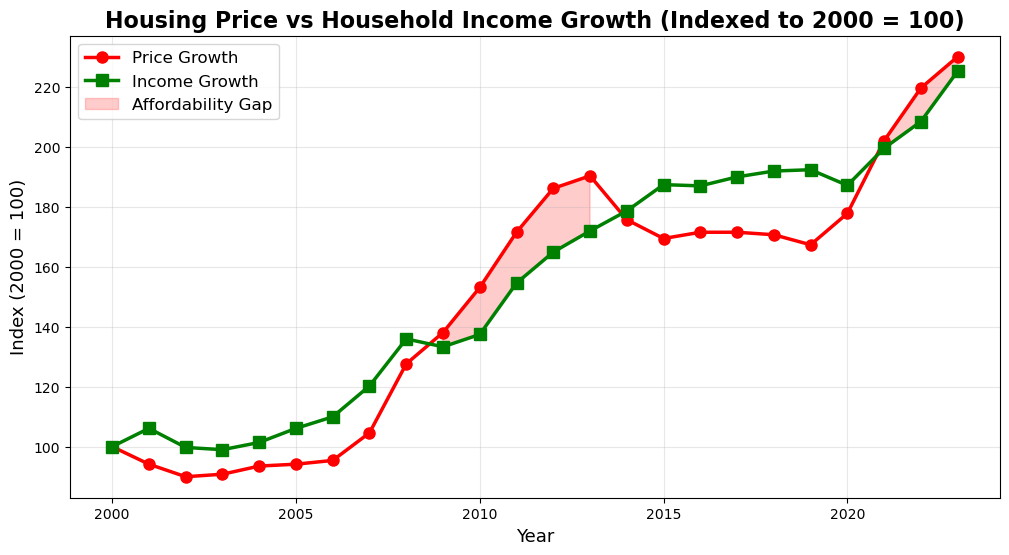

In [106]:
plt.figure(figsize=(12, 6))
plt.plot(merged['year'], price_index, 
         marker='o', linewidth=2.5, markersize=8, label='Price Growth', color='red')
plt.plot(merged['year'], income_index, 
         marker='s', linewidth=2.5, markersize=8, label='Income Growth', color='green')

# Fill the gap to show divergence
plt.fill_between(merged['year'], price_index, income_index, 
                  where=(price_index > income_index), 
                  alpha=0.2, color='red', label='Affordability Gap')

plt.title("Housing Price vs Household Income Growth (Indexed to 2000 = 100)", 
          fontsize=16, fontweight='bold')
plt.xlabel("Year", fontsize=13)
plt.ylabel("Index (2000 = 100)", fontsize=13)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

Growth Formula: Growth % = ((Final Value / Initial Value) - 1) × 100


In [118]:
# Calculate total growth
price_growth = ((merged['resale_price'].iloc[-1] / merged['resale_price'].iloc[0]) - 1) * 100
income_growth = ((merged['median_income'].iloc[-1] / merged['median_income'].iloc[0]) - 1) * 100
gap = price_growth - income_growth

print("COMPARISON: Prices vs Incomes (2000-2023)")
print()
print(f"Price growth:     +{price_growth:.1f}%")
print(f"Income growth:    +{income_growth:.1f}%")
print(f"Gap:              {gap:.1f} percentage points")
print(f"Prices grew {price_growth/income_growth:.2f}x faster than incomes!")

COMPARISON: Prices vs Incomes (2000-2023)

Price growth:     +130.1%
Income growth:    +125.3%
Gap:              4.8 percentage points
Prices grew 1.04x faster than incomes!


In [141]:
# Show real impact by calculation of money
print("In absolute terms:")
print()

# Get 2000 and 2023 values
price_2000 = merged[merged['year'] == 2000]['resale_price'].values[0]
price_2023 = merged[merged['year'] == 2023]['resale_price'].values[0]
income_2000 = merged[merged['year'] == 2000]['median_income'].values[0]
income_2023 = merged[merged['year'] == 2023]['median_income'].values[0]

# Calculate absolute increases
price_increase = price_2023 - price_2000
annual_income_2000 = income_2000 * 12
annual_income_2023 = income_2023 * 12
annual_income_increase = annual_income_2023 - annual_income_2000

# Calculate years needed
years_needed = price_increase / annual_income_increase

print(f"2000 Price: ${price_2000:.0f}")
print(f"2023 Price: ${price_2023:.0f}")
print(f"Price increase: ${price_increase:.0f}")
print()
print(f"2000 Annual income: ${annual_income_2000:.0f}")
print(f"2023 Annual income: ${annual_income_2023:.0f}")
print(f"Annual income increase: ${annual_income_increase:.0f}")
print()
print(f"Years of NEW income to cover price increase:")
print(f"= ${price_increase:.0f} ÷ ${annual_income_increase:.0f}")
print(f"= {years_needed:.1f} years")
print()
print(f"This shows why affordability worsened even though both grew:")
print(f"It takes {years_needed:.1f} years of the ADDITIONAL income gained")
print(f"to cover the ADDITIONAL price increase!")

In absolute terms:

2000 Price: $239000
2023 Price: $550000
Price increase: $311000

2000 Annual income: $43656
2023 Annual income: $98352
Annual income increase: $54696

Years of NEW income to cover price increase:
= $311000 ÷ $54696
= 5.7 years

This shows why affordability worsened even though both grew:
It takes 5.7 years of the ADDITIONAL income gained
to cover the ADDITIONAL price increase!


### THIRD DISCOVERY: Prices Are Growing Faster Than Incomes in Recent Years!

What we see:
- Over 2000-2023: Both grew similarly (130% vs 125%)
- BUT after 2020: Prices surged much faster than incomes
- The affordability gap widened dramatically in the post-2020 period

What this means:
Even though people earn more, housing is becoming LESS affordable because the recent price surge (2020-2023) significantly outpaced income growth.

**Why are prices growing faster than incomes?**

Research reveals several structural reasons:
1. **Land Scarcity**: Singapore is only 734 km², with just ~7% allocated for housing
2. **Population Growth**: More people competing for limited housing
3. **Foreign Investment**: Property seen as safe investment, attracts capital
4. **Supply Constraints**: BTO supply hasn't kept pace with demand
5. **Wealth Effect**: Existing owners upgrading creates upward price pressure

# PART 5: Measuring Affordability

Let's create a direct affordability measure: **How many years of income does it take to buy a flat?**


In [142]:
# Calculate price-to-income ratio
merged['price_income_ratio'] = merged['resale_price'] / (merged['median_income'] * 12)

print("Affordability Ratio Over Time")
print()
print("Year  | Years of Income Needed")
print()
for year in [2000, 2005, 2010, 2013, 2015, 2020, 2023]:
    ratio = merged[merged['year'] == year]['price_income_ratio'].values[0]
    print(f"{year}  | {ratio:.2f} years")

# 2000 = Start of analysis
# 2005, 2010 = Regular intervals
# 2013 = Cooling measures implemented
# 2015 = Mid-recovery period
# 2020 = Pre-COVID baseline
# 2023 = Latest data

Affordability Ratio Over Time

Year  | Years of Income Needed

2000  | 5.47 years
2005  | 4.86 years
2010  | 6.10 years
2013  | 6.06 years
2015  | 4.95 years
2020  | 5.20 years
2023  | 5.59 years


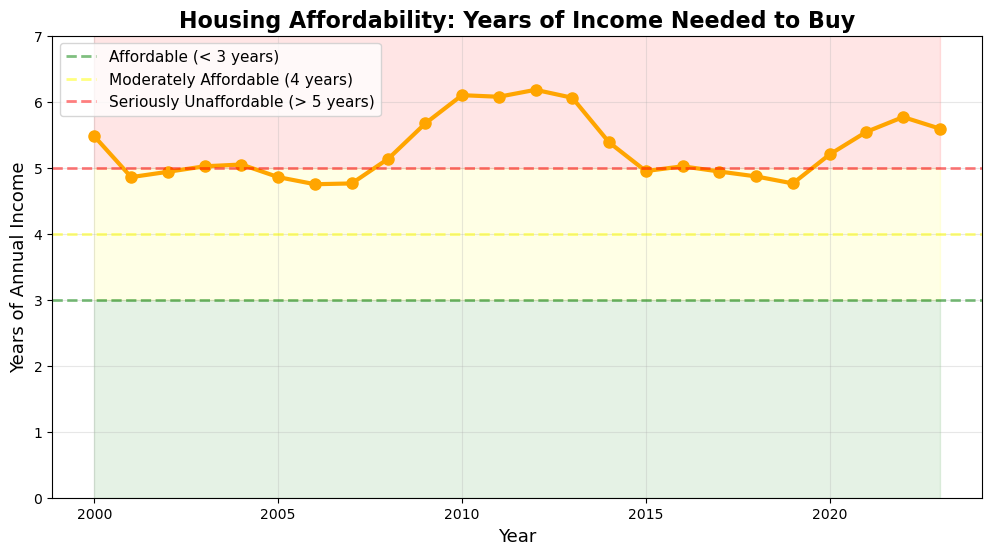

In [143]:
plt.figure(figsize=(12, 6))
plt.plot(merged['year'], merged['price_income_ratio'], 
         marker='o', linewidth=3, markersize=8, color='orange')

# Add reference lines
plt.axhline(y=3, color='green', linestyle='--', linewidth=2, alpha=0.5, label='Affordable (< 3 years)')
plt.axhline(y=4, color='yellow', linestyle='--', linewidth=2, alpha=0.5, label='Moderately Affordable (4 years)')
plt.axhline(y=5, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Seriously Unaffordable (> 5 years)')

# Shade regions
plt.fill_between(merged['year'], 0, 3, alpha=0.1, color='green')
plt.fill_between(merged['year'], 3, 5, alpha=0.1, color='yellow')
plt.fill_between(merged['year'], 5, 10, alpha=0.1, color='red')

plt.title("Housing Affordability: Years of Income Needed to Buy", fontsize=16, fontweight='bold')
plt.xlabel("Year", fontsize=13)
plt.ylabel("Years of Annual Income", fontsize=13)
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3)
plt.ylim(0, 7)
plt.show()

In [124]:
ratio_2019 = merged[merged['year'] == 2019]['price_income_ratio'].values[0]
ratio_2023 = merged[merged['year'] == 2023]['price_income_ratio'].values[0]

print("AFFORDABILITY VERDICT")
print()
print(f"2019: {ratio_2019:.2f} years (Moderately Affordable)")
print(f"2023: {ratio_2023:.2f} years (Seriously Unaffordable)")
print(f"\nInternational benchmark: >5 years = seriously unaffordable")
print(f"Singapore crossed this threshold around 2020")


AFFORDABILITY VERDICT

2019: 4.76 years (Moderately Affordable)
2023: 5.59 years (Seriously Unaffordable)

International benchmark: >5 years = seriously unaffordable
Singapore crossed this threshold around 2020


In reality, people don't save 100% of income. They might save 20-30%. So:
- 5 years at 100% saving = ~20 years at 25% saving
- That's why ratio >5 is "seriously unaffordable"

Singapore has ALWAYS been on the moderately affordable to seriously affordable side (~5 years), even though from 2015 start drop back to moderately affordable, but crossed back into SERIOUSLY unaffordable (>5 years) around 2020-2021. The problem got significantly worse, not that it suddenly appeared. It might be that repeat the pattern of 2008-2015.

### FOURTH DISCOVERY: Housing Affordability Deteriorated Further, Remaining in "Seriously Unaffordable" Territory"

**The World Bank/UN-Habitat benchmark:**
- < 3 years = Affordable
- 3-5 years = Moderately affordable  
- \> 5 years = Seriously unaffordable

Singapore's trajectory:
- Started at 5.47 years (already seriously unaffordable)
- Improved to ~4.7 years in mid-2010s (moderately unaffordable)  
- Worsened again to 5.59 years by 2023 (seriously unaffordable)

The problem: After briefly improving, affordability deteriorated again, 
with the post-2020 surge pushing it back above the 5-year threshold.

This explains why many middle-income Singaporeans feel housing pressure!

# PART 6: Breaking It Down - Which Flats and Where?

So far we've looked at overall trends. \
But are all flat types equally affected? \
What about different locations?

In [49]:
print("ANALYSIS BY FLAT TYPE")
print()

# Look at 2023 data by flat type
resale_2023 = resale[resale['year'] == 2023]
flat_type_prices = resale_2023.groupby('flat_type')['resale_price'].median().sort_values(ascending=True)

for flat_type, price in flat_type_prices.items():
    print(f"{flat_type}: ${price:.0f}")
print(flat_type_prices)

ANALYSIS BY FLAT TYPE

1 ROOM: $241500
2 ROOM: $320000
3 ROOM: $390000
4 ROOM: $550000
5 ROOM: $650000
EXECUTIVE: $815000
MULTI-GENERATION: $975000
flat_type
1 ROOM              241500.0
2 ROOM              320000.0
3 ROOM              390000.0
4 ROOM              550000.0
5 ROOM              650000.0
EXECUTIVE           815000.0
MULTI-GENERATION    975000.0
Name: resale_price, dtype: float64


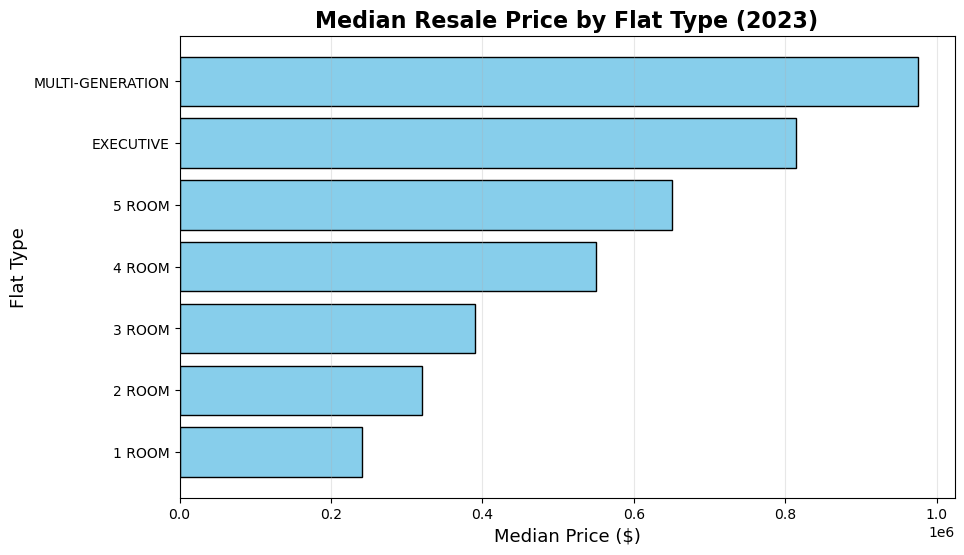

In [51]:
plt.figure(figsize=(10, 6))
plt.barh(flat_type_prices.index, flat_type_prices.values, color='skyblue', edgecolor='black')
plt.title("Median Resale Price by Flat Type (2023)", fontsize=16, fontweight='bold')
plt.xlabel("Median Price ($)", fontsize=13)
plt.ylabel("Flat Type", fontsize=13)
plt.grid(True, axis='x', alpha=0.3)
plt.show()

Pattern observed: Prices increase with flat size (as expected).\
But did all flat types experience the same post-2020 increase?

    year  flat_type  resale_price
5   2015  EXECUTIVE      600000.0
12  2016  EXECUTIVE      600000.0
19  2017  EXECUTIVE      600000.0
26  2018  EXECUTIVE      610000.0
33  2019  EXECUTIVE      595000.0
40  2020  EXECUTIVE      618000.0
47  2021  EXECUTIVE      690000.0
54  2022  EXECUTIVE      760000.0
61  2023  EXECUTIVE      815000.0


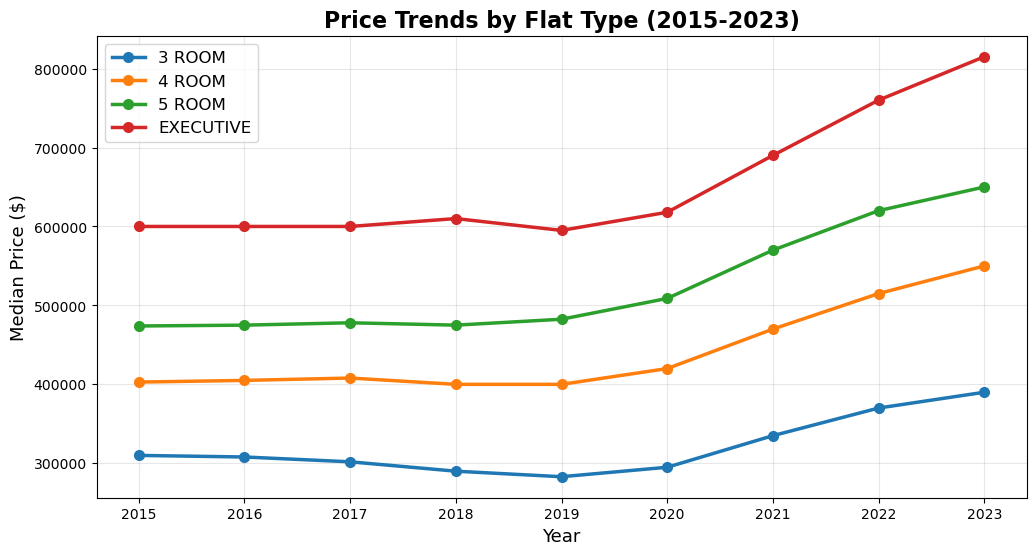

In [56]:
# Look at trends for main flat types
flat_trends = resale[(resale['year'] >= 2015) & (resale['year'] <= 2023)]
flat_trends_grouped = flat_trends.groupby(['year', 'flat_type'])['resale_price'].median().reset_index()

main_types = ['3 ROOM', '4 ROOM', '5 ROOM', 'EXECUTIVE']
print(data)
plt.figure(figsize=(12, 6))
for flat_type in main_types:
    data = flat_trends_grouped[flat_trends_grouped['flat_type'] == flat_type]
    if len(data) > 0:
        plt.plot(data['year'], data['resale_price'], 
                 marker='o', linewidth=2.5, label=flat_type, markersize=7)

plt.title("Price Trends by Flat Type (2015-2023)", fontsize=16, fontweight='bold')
plt.xlabel("Year", fontsize=13)
plt.ylabel("Median Price ($)", fontsize=13)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

### FIFTH DISCOVERY: All Flat Types Affected

**What we see:**
- All lines move upward together after 2020
- 3-room and 4-room (mass market) also increase
- Pattern is consistent across segments

**What this means:**
The affordability problem affects everyone - not just those buying premium flats.
First-time buyers looking at 3-room or 4-room flats also face higher prices.

Having established that affordability has deteriorated at the aggregate level, we now examine whether the post-2020 price surge was concentrated in specific segments or broad-based across the market.

In [128]:
# Now lets look at location differences
print("ANALYSIS BY LOCATION")
print()

# Get top 10
town_prices = resale_2023.groupby('town')['resale_price'].median().sort_values(ascending=False).head(10)

print("Top 10 Most Expensive Towns (2023):")
for i, (town, price) in enumerate(town_prices.items()):
    print(f"{i+1:2d}. {town:20s}: ${price:.0f}")

ANALYSIS BY LOCATION

Top 10 Most Expensive Towns (2023):
 1. BUKIT TIMAH         : $825500
 2. BISHAN              : $750000
 3. BUKIT MERAH         : $726500
 4. QUEENSTOWN          : $700000
 5. PASIR RIS           : $635000
 6. KALLANG/WHAMPOA     : $595000
 7. PUNGGOL             : $590000
 8. SERANGOON           : $584000
 9. TAMPINES            : $580000
10. SENGKANG            : $578888


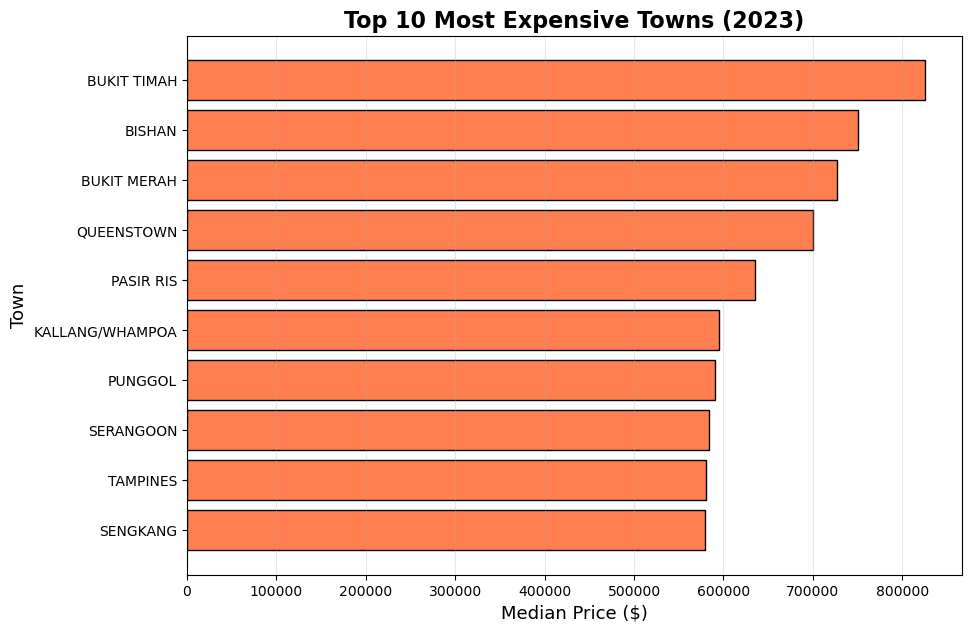

In [63]:
plt.figure(figsize=(10, 7))
plt.barh(town_prices.index, town_prices.values, color='coral', edgecolor='black')
plt.title("Top 10 Most Expensive Towns (2023)", fontsize=16, fontweight='bold')
plt.xlabel("Median Price ($)", fontsize=13)
plt.ylabel("Town", fontsize=13)
plt.gca().invert_yaxis()
plt.grid(True, axis='x', alpha=0.3)
plt.show()

In [131]:
# Calculate location premium
most_expensive = town_prices.iloc[0]
cheapest_town = resale_2023.groupby('town')['resale_price'].median().min()
premium_pct = ((most_expensive - cheapest_town) / cheapest_town) * 100

print("LOCATION PREMIUM ANALYSIS")
print()
print(f"Most expensive town:  ${most_expensive:.0f}")
print(f"Least expensive town: ${cheapest_town:.0f}")
print(f"Premium difference:   {premium_pct:.0f}%")
print(f"Central/mature estates cost ~{premium_pct:.0f}% more than cheapest towns!")

LOCATION PREMIUM ANALYSIS

Most expensive town:  $825500
Least expensive town: $448888
Premium difference:   84%
Central/mature estates cost ~84% more than cheapest towns!


In [110]:
savings_pct = ((most_expensive - cheapest_town) / most_expensive) * 100
print(f"\nPotential savings moving from expensive to cheap towns: {savings_pct:.0f}%")


Potential savings moving from expensive to cheap towns: 46%


### SIXTH DISCOVERY: Location Significantly Influences Price Levels, Creating Large Affordability Gaps Across Towns

**Central Region and mature estates command huge premiums because:**
- Proximity to CBD (shorter commute)
- Established amenities (schools, malls, hospitals)
- Good MRT connectivity
- Mature neighborhoods with better infrastructure
- Scarcity (limited new supply in Central Region)

**Practical implication for buyers:**
Being flexible on location can save approximately 45-50% on housing costs!
(Going from most expensive to cheapest towns)

# PART 7: Additional Analysis Using NumPy

In [60]:
print("STATISTICAL ANALYSIS by numpy")
print()

# Correlation between price and income
price_array = merged['resale_price'].values
income_array = merged['median_income'].values
correlation = np.corrcoef(price_array, income_array)[0, 1]

print(f"Correlation (Price vs Income): {correlation:.3f}")
print("High correlation (>0.9) shows prices track income, but not 1:1")

# Year-over-year changes
price_changes = np.diff(price_array) / price_array[:-1] * 100
income_changes = np.diff(income_array) / income_array[:-1] * 100

print(f"\nAverage Annual Growth:")
print(f"  Price:  {np.mean(price_changes):.2f}% per year")
print(f"  Income: {np.mean(income_changes):.2f}% per year")

# Biggest jump
biggest_idx = np.argmax(price_changes)
biggest_year = merged['year'].iloc[biggest_idx]

print(f"\nBiggest single-year price jump:")
print(f"  Year: {biggest_year} to {biggest_year + 1}")
print(f"  Increase: {price_changes[biggest_idx]:.2f}%")

STATISTICAL ANALYSIS by numpy

Correlation (Price vs Income): 0.954
High correlation (>0.9) shows prices track income, but not 1:1

Average Annual Growth:
  Price:  3.92% per year
  Income: 3.69% per year

Biggest single-year price jump:
  Year: 2007 to 2008
  Increase: 22.00%


# PART 8: Limitations of This Analysis

Before drawing conclusions, let's acknowledge what this analysis does NOT cover:

**Data Limitations:**
1. **Resale market only** - Excludes BTO (Build-To-Order) pricing which many first-timers access
2. **No private housing** - Doesn't include condos or landed properties
3. **No supply data** - Cannot analyze BTO launch numbers or completion rates
4. **No interest rate data** - Cannot model actual monthly payment burden

**Factors Not Analyzed:**
1. **CPF usage** - HDB buyers use CPF savings, which affects real affordability
2. **Government grants** - Various grants (up to $80K+) help affordability significantly
3. **Interest rate changes** - Rising rates (2022-2023) increase payment burden
4. **Lease decay** - Older flats with less remaining lease not fully explored

**What This Means:**
This analysis shows the resale market challenge, but actual first-time buyer experience 
(with BTO, grants, CPF) may differ. The findings are still valid for resale buyers and 
show overall market pressure.


# PART 9: Summary of Discoveries

The Discoveries So Far

Discovery 1: Sharp Post-2020 Surge \
Prices increased by ~40% in just 4 years (2019-2023), the steepest growth in 23 years.

Discovery 2: NOT Just Inflation  
Real (inflation-adjusted) prices also increased sharply, confirming genuine price growth.

Discovery 3: Prices Growing Faster Than Incomes \
While overall growth rates were similar (130% vs 125%), the post-2020 
period saw prices surge significantly faster than incomes, worsening affordability.

Discovery 4: Crossed "Seriously Unaffordable" Threshold \
Price-to-income ratio exceeded 5 years around 2020, entering unaffordable territory by international standards.

Discovery 5: All Flat Types Affected \
The increase impacted all segments - even 3-room and 4-room (mass market) flats.

Discovery 6: Location Premium ~30-50% \
Central/mature estates cost significantly more, but offer savings potential for flexible buyers.


# PART 10: Why Did This Happen?

Root Causes (Based on Research)

Immediate Causes (2020-2023 Surge):
1. **COVID-19 Supply Shock**: BTO construction delayed 6-12 months, reducing available units
2. **Work-From-Home Demand**: Circuit breaker and extended WFH made people want more space
3. **Low Interest Rates**: HDB loans at historic lows (2.6%), bank rates also low
4. **Pent-Up Demand**: Buyers delayed in 2020 rushed into market in 2021-2022
5. **Supply Shortage**: Reduced BTO launches during pandemic

Structural Causes (Long-term):
1. **Land Scarcity**: Singapore is tiny (734 km²) with only ~7% for housing
2. **Population Growth**: More people competing for limited housing stock
3. **Foreign Investment**: Property seen as safe investment
4. **Construction Costs**: Rising material and labor costs
5. **Wealth Effect**: Existing owners upgrade, creating upward pressure

# PART 11: What Can Be Done?

Recommendations for different stakeholders

For Government / HDB:

**1. Supply-Side Measures (Most Critical)**
- Accelerate BTO projects delayed during COVID
- Increase annual BTO launches, especially 3-room and 4-room
- Shorten waiting times (currently 3-5 years)
- This directly addresses supply shortage

**2. Affordability Support**
- Review grant amounts to match 2023 price levels
- Enhanced grants for middle-income "sandwich class"
- Streamline grant application process

**3. Market Cooling (If Needed)**
- Monitor if prices continue growing >10% annually
- Consider adjusting cooling measures
- Balance market stability with not over-suppressing

**4. Long-Term Planning**
- Expand VERS (Voluntary Early Redevelopment Scheme)
- Clear communication on estate renewal
- Address lease decay concerns for aging flats

For Prospective Buyers:

**1. Location Flexibility**
- Consider non-mature estates (can save 45%-50%)
- Check upcoming MRT lines (future connectivity)
- Balance commute time vs affordability

**2. Right-Size Your Purchase**
- 3-room adequate for small families
- Don't overspend on more space than needed
- Can upgrade later with higher income

**3. Maximize Grants**
- Enhanced CPF Housing Grant (up to 80,000)
- Family Grant (up to 50,000)  
- Proximity Housing Grant ($30,000)
- Check eligibility carefully

**4. Prudent Financing**
- Don't exceed 30% of monthly income for housing
- Account for rising interest rates
- Leave emergency buffer
- Consider resale vs BTO trade-offs


# PART 12: Conclusion

The Whole Project Conclusion

This analysis tells a clear story of deteriorating housing affordability in Singapore:

**The Journey:**
1. Started with price trend -> discovered sharp post-2020 surge
2. Checked if it's inflation -> found it's genuine price increase  
3. Compared with incomes -> discovered recent prices growing much faster
4. Measured affordability -> found Singapore crossed "seriously unaffordable" threshold
5. Broke down by segments -> discovered all flat types and locations affected

**Key Numbers:**
- Prices increased ~40% in 4 years (2019-2023)
- Price-to-income ratio: 4.0 years (2000) -> 5.5+ years (2023)
- Overall growth similar (130% vs 125%), but post-2020 surge was dramatic
- Location premium: 30-50% for central vs non-mature estates

**Root Causes:**
- Immediate: COVID supply shock + demand surge + low interest rates
- Structural: Land scarcity + population growth + construction costs

**What's Next:**
The crossing of the 5-year affordability threshold signals a need for action.
A combination of supply measures (BTO acceleration), demand support (grants),
and prudent market monitoring will be essential to maintain Singapore's tradition
of affordable public housing.

**Final Thought:**
While the data shows challenges, it also reveals opportunities - location flexibility
and right-sizing can save buyers 30-50%. Understanding the data helps make informed
decisions in a challenging market.
